# Notebook 03 — Sistema finale (ensemble)

**Fase 3.a della traccia**: composizione motivata dei tre approcci della Fase 2.

## Obiettivi didattici

1. Capire **come si combinano** score eterogenei con scale diverse
2. Implementare un **ensemble per massimo dei punteggi normalizzati**
3. **Calibrare la soglia** in modo coerente col problem framing
4. Produrre un **CSV finale di alert** che è il deliverable per il committente

## Strategia di composizione scelta: MAX dei rank normalizzati

$$s_{\text{final}}(t,s) = \max(\text{rank}(s_1), \text{rank}(s_2), \text{rank}(s_3)) \in [0, 1]$$

**Razionale** (vedi `problem_framing.md`):
- **Max** (non media): basta che UN approccio consideri l'osservazione anomala per generare un alert. Massimizza il recall complessivo dell'ensemble.
- **Rank-normalization**: i tre score hanno scale incomparabili. Convertirli in percentili (range [0,1]) li rende confrontabili.
- **Soglia su percentile training**: produce un volume di alert prevedibile e calibrato sul dominio.

### Alternative considerate e scartate

| Strategia | Pro | Contro | Verdetto |
|---|---|---|---|
| Media degli score | Più stabile | Diluisce gli alert specifici di una sola baseline | Scartato |
| Voto a maggioranza | Riduce FP | Richiede agreement spesso assente (Jaccard < 0.5) | Scartato |
| Meta-modello supervisionato | Più espressivo | Richiede labels (che non abbiamo) | Scartato |
| Cascata B1→B2→B3 | Filtro progressivo | Complessità alta, gain non motivato | Scartato |
| **Max(rank) — scelto** | Semplice, recall alto, calibrabile | Sensibile a singolo score "rumoroso" | **Scelto** |

## 1. Setup e caricamento score dalle baseline

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.preprocessing import carica_master
from src.models import ensemble_max, _normalizza_rank

config.set_global_seed()
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 90

# Carichiamo gli score salvati dal notebook 02.
df_scores = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'baselines_scores.parquet')
df_master = carica_master()

print(f'Score caricati: {df_scores.shape}')
print(df_scores.columns.tolist())

[master] da cache (master.parquet)
Score caricati: (315792, 10)
['chiave', 'timestamp', 'score_b1', 'alert_b1', 'score_b2', 'alert_b2', 'score_b3', 'alert_b3', 'predizione', 'residuo']


## 2. Normalizzazione dei tre score

### Teoria — Perché rank-normalization

Gli score grezzi delle tre baseline hanno proprietà molto diverse:

| Score | Range | Distribuzione | Stabilità |
|---|---|---|---|
| B1 (|z| robusto) | [0, ∞) | Heavy-tailed | Sensibile a outlier estremi |
| B2 (decision_func IF) | ~[-0.2, 0.2] | Quasi-normale | Stabile |
| B3 (|residuo|/σ) | [0, ∞) | Pesante a sinistra | Variabile per spira |

Una min-max normalization sarebbe schiacciata da un singolo outlier estremo. Una z-score lascia tail visibili. La normalizzazione **per rango**:

$$\text{rank-norm}(s_i) = \frac{\text{rank}(s_i)}{N}$$

ha tre proprietà desiderabili:
1. **Invariante per trasformazioni monotone**: applicare log/sqrt agli score non cambia il rank
2. **Range fisso [0, 1]**: confronto immediato tra baseline
3. **Robusta agli outlier**: ogni osservazione contribuisce con 1 al rank, indipendentemente dal valore

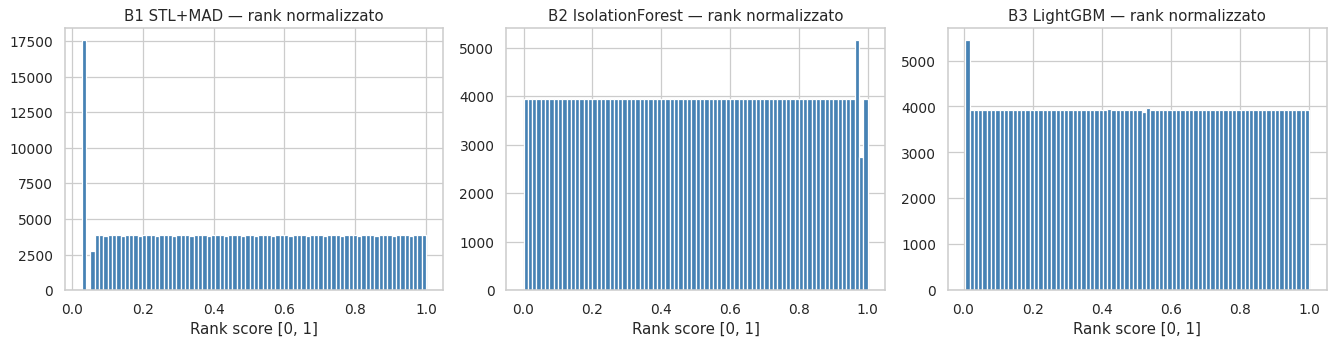

In [2]:
# Normalizzazione rank.
df_scores['score_b1_norm'] = _normalizza_rank(df_scores['score_b1'].fillna(0))
df_scores['score_b2_norm'] = _normalizza_rank(df_scores['score_b2'].fillna(0))
df_scores['score_b3_norm'] = _normalizza_rank(df_scores['score_b3'].fillna(0))

# Visualizziamo le 3 distribuzioni dopo la normalizzazione.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                           ['score_b1_norm', 'score_b2_norm', 'score_b3_norm'],
                           ['B1 STL+MAD', 'B2 IsolationForest', 'B3 LightGBM']):
    ax.hist(df_scores[col], bins=80, color='steelblue', edgecolor='white')
    ax.set_title(f'{title} — rank normalizzato')
    ax.set_xlabel('Rank score [0, 1]')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '20_score_normalizzati.png', dpi=120)
plt.show()

## 3. Composizione: max dei rank

Operazione semplice ma decisiva: lo score ensemble è il massimo dei tre rank normalizzati.

$$s_{\text{ens}}(t,s) = \max\big(r_1(t,s), r_2(t,s), r_3(t,s)\big)$$

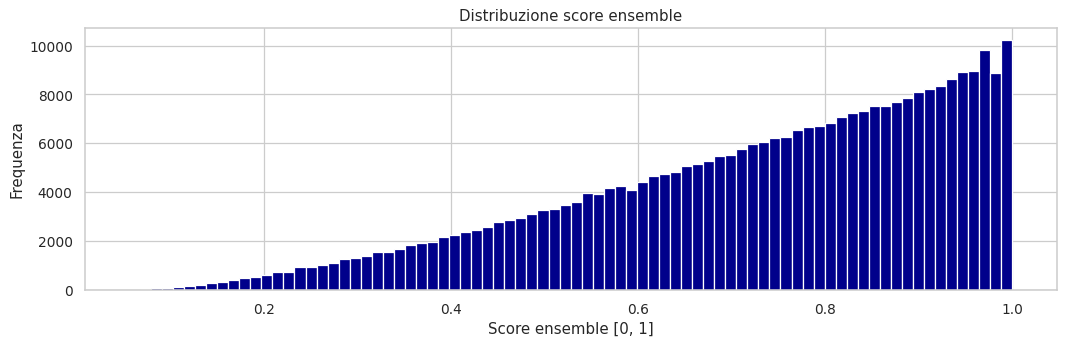

In [3]:
df_scores['score_ensemble'] = df_scores[
    ['score_b1_norm', 'score_b2_norm', 'score_b3_norm']
].max(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df_scores['score_ensemble'], bins=80, color='darkblue', edgecolor='white')
ax.set_title('Distribuzione score ensemble')
ax.set_xlabel('Score ensemble [0, 1]')
ax.set_ylabel('Frequenza')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '21_score_ensemble.png', dpi=120)
plt.show()

## 4. Calibrazione della soglia operativa

### Teoria — Selezione della soglia in assenza di etichette

Senza ground truth non possiamo ottimizzare precision/recall direttamente. Le strategie possibili sono:

1. **Target rate fisso**: "voglio sempre il top X% di alert" → produce un volume costante ma è arbitrario
2. **Percentile del training**: "qualcosa di più anomalo del Y° percentile storico" → conservativo, adattivo alla scala dei dati
3. **Distance dalla mediana**: "score > mediana + k×IQR" → robusto ma poco interpretabile

Adottiamo la **strategia 2** col **percentile 99**: gli alert sono ore-spira con score "di anomalia" superiore al 99% delle osservazioni di training. Questo:
- Genera un volume di ~1% di ore-spira con alert (target leggibile per l'analista)
- Si adatta automaticamente se le scale cambiano (es. crescita organica della rete)
- È giustificabile semplicemente al committente: "vi segnaliamo l'1% di osservazioni più anomale"

### Importante: la soglia si calibra SOLO sul training

Calcolare il percentile sull'intero dataset (train+test) inserirebbe **leakage** del test nel test stesso. La traccia (sez. 8) lo segnala esplicitamente come "trappola comune".

In [4]:
# Split temporale.
train_mask = df_scores['timestamp'] < pd.Timestamp(config.TEST_START)
test_mask = df_scores['timestamp'] >= pd.Timestamp(config.TEST_START)

# Soglia: 99° percentile sui soli score di training.
soglia = float(np.percentile(df_scores.loc[train_mask, 'score_ensemble'], config.PERCENTILE_SOGLIA_ENSEMBLE))
print(f'Soglia ensemble (P{config.PERCENTILE_SOGLIA_ENSEMBLE}, training): {soglia:.4f}')

# Verifica: solo dati affidabili generano alert.
df_scores = df_scores.merge(
    df_master[['chiave', 'timestamp', 'accuratezza']], on=['chiave', 'timestamp'], how='left'
)
df_scores['alert_ensemble'] = (
    (df_scores['score_ensemble'] > soglia)
    & (df_scores['accuratezza'] >= config.SOGLIA_ACCURATEZZA_ALERT)
)

print(f'\nAlert rate (train): {df_scores.loc[train_mask, "alert_ensemble"].mean():.4f}')
print(f'Alert rate (test) : {df_scores.loc[test_mask, "alert_ensemble"].mean():.4f}')

Soglia ensemble (P99.0, training): 0.9961

Alert rate (train): 0.0080
Alert rate (test) : 0.0197


## 5. Ispezione visiva degli alert finali

Visualizziamo gli alert su 2-3 spire diverse, scegliendole per tipologia urbana (centro vs periferia, alta vs bassa velocità tipica).

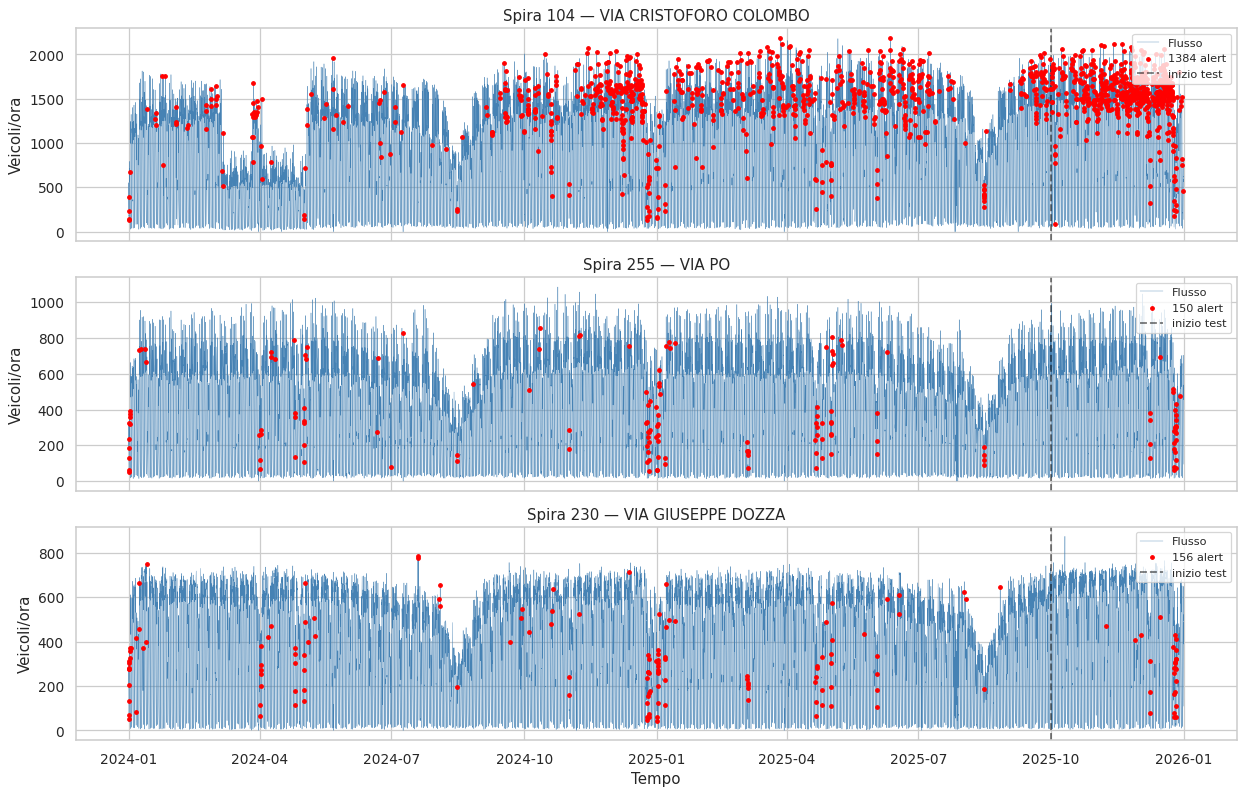

In [5]:
# Top 3 spire per volume di traffico.
top_spire = (df_master.groupby('chiave')['conteggio_veicoli'].mean()
                       .sort_values(ascending=False).head(3).index.tolist())

fig, axes = plt.subplots(len(top_spire), 1, figsize=(14, 3 * len(top_spire)), sharex=True)
if len(top_spire) == 1:
    axes = [axes]

for ax, sp in zip(axes, top_spire):
    df_sp = df_scores[df_scores['chiave'] == sp].merge(
        df_master[['chiave', 'timestamp', 'conteggio_veicoli', 'nome_via']],
        on=['chiave', 'timestamp'], how='left'
    )
    via = df_sp['nome_via'].iloc[0] if 'nome_via' in df_sp.columns else sp
    ax.plot(df_sp['timestamp'], df_sp['conteggio_veicoli'], linewidth=0.3, color='steelblue', label='Flusso')
    alerts = df_sp[df_sp['alert_ensemble']]
    ax.scatter(alerts['timestamp'], alerts['conteggio_veicoli'], color='red', s=8, label=f'{len(alerts)} alert', zorder=5)
    # Marker per la fine del training (separa test set).
    ax.axvline(pd.Timestamp(config.TEST_START), color='black', linestyle='--', alpha=0.5, label='inizio test')
    ax.set_title(f'Spira {sp} — {via}')
    ax.set_ylabel('Veicoli/ora')
    ax.legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('Tempo')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '22_alerts_top_spire.png', dpi=120)
plt.show()

## 6. Cluster temporali di alert (anomalie collettive)

Singole ore di alert sono utili, ma quello che colpisce l'attenzione dell'analista sono i **cluster** — sequenze di ore consecutive in alert sulla stessa spira o su spire vicine. Identifichiamoli.

In [6]:
# Algoritmo: per ogni spira, raggruppa alert temporalmente contigui (gap < 3 ore).
def trova_cluster(df_spira: pd.DataFrame, gap_max_ore: int = 3) -> pd.DataFrame:
    df_spira = df_spira[df_spira['alert_ensemble']].sort_values('timestamp')
    if len(df_spira) == 0:
        return pd.DataFrame()
    delta = df_spira['timestamp'].diff().dt.total_seconds() / 3600
    df_spira = df_spira.copy()
    df_spira['cluster'] = (delta > gap_max_ore).cumsum()
    return (df_spira.groupby('cluster')
                    .agg(chiave=('chiave', 'first'),
                         inizio=('timestamp', 'min'),
                         fine=('timestamp', 'max'),
                         n_ore=('timestamp', 'count'),
                         score_max=('score_ensemble', 'max'))
                    .reset_index(drop=True))

clusters_test = pd.concat([
    trova_cluster(df_scores[(df_scores['chiave'] == sp) & test_mask])
    for sp in df_scores['chiave'].unique()
], ignore_index=True).sort_values('n_ore', ascending=False)

print(f'Cluster di alert nel test set: {len(clusters_test)}')
print('\nTop 10 cluster (per durata):')
print(clusters_test.head(10).to_string(index=False))

Cluster di alert nel test set: 247

Top 10 cluster (per durata):
 chiave              inizio                fine  n_ore  score_max
    104 2025-12-13 08:00:00 2025-12-13 20:00:00     13   0.999848
    104 2025-11-29 08:00:00 2025-11-29 20:00:00     13   0.999911
    104 2025-12-16 07:00:00 2025-12-16 19:00:00     13   0.999972
    104 2025-12-20 08:00:00 2025-12-20 20:00:00     13   0.999892
    104 2025-10-30 08:00:00 2025-10-30 19:00:00     12   0.999921
    104 2025-11-21 07:00:00 2025-11-21 19:00:00     12   0.999984
    104 2025-12-06 08:00:00 2025-12-06 19:00:00     12   0.999886
    104 2025-12-05 08:00:00 2025-12-05 19:00:00     12   0.999709
    104 2025-12-24 07:00:00 2025-12-24 20:00:00     12   0.999902
    104 2025-11-22 08:00:00 2025-11-22 19:00:00     12   0.999948


## 7. Salvataggio risultati

In [7]:
# Output 1: tutti gli score (per Notebook 04 valutazione).
df_scores.to_parquet(PROJECT_ROOT / 'data' / 'processed' / 'ensemble_scores.parquet')

# Output 2: CSV degli alert finali (deliverable per il committente).
alerts_finali = df_scores[df_scores['alert_ensemble']].merge(
    df_master[['chiave', 'timestamp', 'conteggio_veicoli', 'nome_via', 'direzione',
               'tipo_giorno', 'ora', 'precipitation', 'temperature_2m']],
    on=['chiave', 'timestamp'], how='left'
)
alerts_finali = alerts_finali[[
    'chiave', 'timestamp', 'nome_via', 'direzione', 'conteggio_veicoli',
    'score_ensemble', 'score_b1_norm', 'score_b2_norm', 'score_b3_norm',
    'tipo_giorno', 'ora', 'temperature_2m', 'precipitation', 'accuratezza',
]].sort_values(['timestamp', 'score_ensemble'], ascending=[True, False])

alerts_finali.to_csv(PROJECT_ROOT / 'results' / 'alerts_finali.csv', index=False)
clusters_test.to_csv(PROJECT_ROOT / 'results' / 'alerts_clusters_test.csv', index=False)

print(f'Salvati:')
print(f'  - ensemble_scores.parquet ({len(df_scores)} righe)')
print(f'  - alerts_finali.csv ({len(alerts_finali)} alert)')
print(f'  - alerts_clusters_test.csv ({len(clusters_test)} cluster nel test set)')

Salvati:
  - ensemble_scores.parquet (315792 righe)
  - alerts_finali.csv (2988 alert)
  - alerts_clusters_test.csv (247 cluster nel test set)


## 8. Prossimo step

Abbiamo il sistema funzionante, ma — come ricorda la traccia — "funzionante" è insufficiente: bisogna **dimostrare che funziona**. Il notebook 04 lo fa con tre strategie indipendenti.